# 다이캐스팅 공정 데이터 EDA 파이프라인
> **구성**: 데이터 로드 → 구조 파악 → 중복 확인 → 결측값 처리 → 이상치 처리 → 타겟/파생변수 생성 → 분포 시각화 → 불량 분포 시각화

## STEP 0. 라이브러리 임포트 및 데이터 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
# ── 데이터 로드 (멀티헤더)
df_raw = pd.read_csv(
    "/Users/jisoyun/Desktop/sparta_python/심화 프로젝트/hotsix/data/DieCasting_Quality_Raw_Data.csv",
    header=[0, 1]
)
print(f"원본 Shape: {df_raw.shape}")
df_raw.head(5)

원본 Shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   
3               217           0.008                 11  ...           0   
4               217           0.008                 12  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   
3       0      0             0               0          0       0         0   
4       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  
3             0            0  
4             0            0  

[5 rows x 57 columns]

## STEP 1. 데이터 구조 파악

In [2]:
# 컬럼 목록 (멀티헤더 상태)
print("컬럼 그룹:", df_raw.columns.get_level_values(0).unique().tolist())
print("전체 컬럼 수:", len(df_raw.columns))
df_raw.info()

컬럼 그룹: ['Process', 'Sensor', 'Defects']
전체 컬럼 수: 57
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float6

In [3]:
# 기초 통계량 (멀티헤더 상태)
df_raw.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean           14.309622  ...     0.021367     0.0     0.000531      0.008626   
std             3.286284  ...     0.150020     0.0     0.023036      0.093907   
min             0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%            11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%            13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%            17.000000  ...     0.000000     0.0     0.000000      0.000000   
max            24.000000  ...     2.000000     0.0     1.000000      2.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [4]:
# 고유값 수 확인
df_raw.nunique()

Process  id                      7535
         Product_Type               2
         Shot                    1271
         Velocity_1                33
         Velocity_2                27
         Velocity_3                45
         High_Velocity            319
         Cylinder_Pressure         22
         Rapid_Rise_Time           18
         Biscuit_Thickness         24
         Clamping_Force            42
         Cycle_Time                61
          Pressure_Rise_Time       16
         Casting_Pressure          65
         Spray_Time                32
         Spray_1_Time               7
         Spray_2_Time               8
Sensor   Melting_Furnace_Temp     737
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

## STEP 2. 중복 데이터 확인
> id는 고유하지만, id를 제외한 실질 데이터 기준으로 중복 여부 확인

In [5]:
# 전체 중복 (id 포함)
print("전체 중복 행:", df_raw.duplicated().sum())

# id 제외 실질 중복
df_dropid = df_raw.drop(columns=[('Process', 'id')]).copy()
print("id 제외 중복 행:", df_dropid.duplicated().sum())

전체 중복 행: 0
id 제외 중복 행: 2918


In [6]:
# 중복 행 상세 확인
duplicate_rows = df_dropid[df_dropid.duplicated(keep=False)]
print(f"중복 관련 행 수: {len(duplicate_rows)}")
duplicate_rows.sort_values(by=('Process', 'Shot')).head(20)

중복 관련 행 수: 5836


Process                                                      \
     Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
4808            2    0      0.156      0.170      0.208         2.533   
4807            2    0      0.156      0.170      0.208         2.533   
4810            2    1      0.156      0.170      0.208         2.533   
4809            2    1      0.156      0.170      0.208         2.533   
1099            1    1      0.140      0.168      0.182         2.153   
1100            1    1      0.140      0.168      0.182         2.153   
4812            2    2      0.149      0.174      0.204         2.506   
4811            2    2      0.149      0.174      0.204         2.506   
1101            1    2      0.142      0.170      0.180         2.157   
1102            1    2      0.142      0.170      0.180         2.157   
4814            2    3      0.144      0.164      0.203         2.529   
4813            2    3      0.144      0.164      0.203         2.529   
1103            1    3      0.142      0.170      0.180         2.157   
1104            1    3      0.142      0.170      0.180         2.157   
4815            2    4      0.158      0.160      0.204         2.506   
1106            1    4      0.144      0.170      0.182         2.097   
1105            1    4      0.144      0.170      0.182         2.097   
4816            2    4      0.158      0.160      0.204         2.506   
3414            1    5      0.139      0.168      0.186         1.295   
3413            1    5      0.139      0.168      0.186         1.295   

                                                                           \
     Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
4808               265           0.012                 16             355   
4807               265           0.012                 16             355   
4810               265           0.012                 16             355   
4809               265           0.012                 16             355   
1099               218           0.009                 10             255   
1100               218           0.009                 10             255   
4812               264           0.012                 16             357   
4811               264           0.012                 16             357   
1101               218           0.008                 11             257   
1102               218           0.008                 11             257   
4814               264           0.012                 13             361   
4813               264           0.012                 13             361   
1103               218           0.008                 11             257   
1104               218           0.008                 11             257   
4815               265           0.012                 15             361   
1106               218           0.009                 10             259   
1105               218           0.009                 10             259   
4816               265           0.012                 15             361   
3414               216           0.008                 12             258   
3413               216           0.008                 12             258   

      ...     Defects                                                          \
      ... Blow_Hole_2 Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2   
4808  ...           0       0      0             0               0          0   
4807  ...           0       0      0             0               0          0   
4810  ...           0       0      0             0               0          0   
4809  ...           0       0      0             0               0          0   
1099  ...           0       0      0             0               0          0   
1100  ...           0       0      0             0               0          0   
4812  ...           0       0      0             0          

In [7]:
# 중복 행 중 불량 vs 양품 분리 확인
dup_defects = duplicate_rows[duplicate_rows['Defects'].sum(axis=1) > 0]
dup_good    = duplicate_rows[duplicate_rows['Defects'].sum(axis=1) == 0]
print(f"중복 중 불량: {len(dup_defects)}건 / 양품: {len(dup_good)}건")

중복 중 불량: 1232건 / 양품: 4604건


In [8]:
# Shot 번호 고유값 여부 확인 (Product_Type 내 순번이므로 전체에서 중복 발생)
shot_cnt = df_raw['Process']['Shot'].value_counts()
print(f"Shot 고유값 수: {df_raw['Process']['Shot'].nunique()}")
print(f"전체 행 수: {len(df_raw)}")
print("→ Shot은 Product_Type 내 순번으로 전체에서 중복됨")
shot_cnt.head(10)

Shot 고유값 수: 1271
전체 행 수: 7535
→ Shot은 Product_Type 내 순번으로 전체에서 중복됨


Shot
44    12
45    12
46    12
47    12
11    10
12    10
13    10
14    10
15    10
19    10
Name: count, dtype: int64

## STEP 3. 헤더 정리 및 수치형 변환
> 멀티헤더 → 단일헤더, 전체 수치형 변환 (이후 모든 작업은 df 기준)

In [9]:
df = df_raw.copy()

# 멀티헤더 → 단일헤더 (2행 컬럼명 사용)
df.columns = df.columns.get_level_values(1).str.strip()

# id 제외 전체 컬럼 수치형 변환
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

print(f"✅ 변환 완료: {df.shape[0]}행 × {df.shape[1]}열")
print(f"   컬럼 목록: {df.columns.tolist()}")

✅ 변환 완료: 7535행 × 57열
   컬럼 목록: ['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Air_Pressure_Min', 'Air_Pressure_Max', 'Coolant_Temp', 'Coolant_Temp_Min', 'Coolant_Temp_Max', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Temp_Min', 'Factory_Temp_Max', 'Factory_Humidity', 'Factory_Humidity_Min', 'Factory_Humidity_Max', 'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1', 'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2', 'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2', 'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2', 'Scratch_2', 'Buring_Mark_2', 'Inclusions_2']


## STEP 4. 결측값 확인 및 처리

In [10]:
# 결측값 현황
missing_counts = df.isnull().sum()
missing_cols   = missing_counts[missing_counts > 0]

missing_df = pd.DataFrame({
    'missing_count': missing_cols,
    'missing_ratio(%)': df[missing_cols.index].isnull().mean() * 100
}).sort_values('missing_count', ascending=False)

print("결측값 보유 컬럼:")
display(missing_df)

결측값 보유 컬럼:


,missing_count,missing_ratio(%)
Factory_Temp,90,1.194426
Factory_Temp_Min,90,1.194426
Factory_Temp_Max,90,1.194426
Factory_Humidity,90,1.194426
Factory_Humidity_Min,90,1.194426
Factory_Humidity_Max,90,1.194426


In [11]:
# Factory 센서 6개 컬럼 → Product_Type별 중앙값으로 대체
factory_cols = missing_cols.index

df[factory_cols] = (
    df.groupby('Product_Type')[factory_cols]
      .transform(lambda x: x.fillna(x.median()))
)

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df.isnull().sum().sum()}건")
print("   처리 방법: Product_Type 그룹별 중앙값 대체")

✅ 결측값 처리 완료 → 잔여 결측값: 0건
   처리 방법: Product_Type 그룹별 중앙값 대체


## STEP 5. 이상치 탐지 및 처리 (IQR 기준)
> Process 변수와 Sensor 변수 각각 탐지 후 IQR Capping 적용

In [12]:
# 이상치 탐지 함수 (팀원 EDA 재사용)
def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR    = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mask   = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean() * 100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

In [13]:
# Process 변수 이상치 확인
process_num_cols = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness',
    'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time',
    'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time'
]

print("[ Process 변수 이상치 ]")
display(detect_outliers_iqr(df, process_num_cols))

[ Process 변수 이상치 ]


,count,pct(%),lower_bound,upper_bound
Velocity_2,184,2.44,0.16,0.176
Biscuit_Thickness,12,0.16,2.0,26.0
Cycle_Time,11,0.15,-1.6,58.4
High_Velocity,10,0.13,1.55,3.107
Rapid_Rise_Time,10,0.13,0.002,0.018
Velocity_1,6,0.08,0.121,0.177
Velocity_3,4,0.05,0.149,0.234
Cylinder_Pressure,4,0.05,145.0,337.0
Pressure_Rise_Time,4,0.05,0.025,0.053


In [14]:
# Sensor 변수 이상치 확인
sensor_cols = [
    'Melting_Furnace_Temp', 'Air_Pressure',
    'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity'
]

print("[ Sensor 변수 이상치 ]")
display(detect_outliers_iqr(df, sensor_cols))

[ Sensor 변수 이상치 ]


,count,pct(%),lower_bound,upper_bound
Factory_Temp,374,4.96,29.2,36.4


In [15]:
# IQR Capping 적용 (Process 변수만 — Sensor는 이상치 없음)
outlier_report = []
for col in process_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    cnt = ((df[col] < lower) | (df[col] > upper)).sum()
    if cnt > 0:
        outlier_report.append({'변수': col, '이상치 수': cnt})
    df[col] = df[col].clip(lower, upper)

print("✅ IQR Capping 완료 (처리 변수):")
for r in outlier_report:
    print(f"   - {r['변수']}: {r['이상치 수']}건")

✅ IQR Capping 완료 (처리 변수):
   - Velocity_1: 6건
   - Velocity_2: 184건
   - Velocity_3: 4건
   - High_Velocity: 10건
   - Cylinder_Pressure: 4건
   - Rapid_Rise_Time: 10건
   - Biscuit_Thickness: 12건
   - Cycle_Time: 11건
   - Pressure_Rise_Time: 4건


## STEP 6. 타겟 변수 및 파생변수 생성

In [16]:
# ── 타겟 변수 1: 이진 분류 (양품=0 / 불량=1)
defect_cols_all = [
    c for c in df.columns if any(c.startswith(d) for d in [
        'Short_Shot', 'Bubble', 'Exfoliation', 'Blow_Hole',
        'Stain', 'Dent', 'Deformation', 'Contamination',
        'Impurity', 'Crack', 'Scratch', 'Buring_Mark', 'Inclusions'
    ])
]
df['Defect_Status'] = (df[defect_cols_all].sum(axis=1) > 0).astype(int)

# ── 타겟 변수 2: 다중 분류 (불량 유형 레이블)
defect_types = {
    'Short_Shot':  ['Short_Shot_1',  'Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1',   'Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1', 'Exfoliation_2'],
    'Stain':       ['Stain_1',       'Stain_2'],
    'Deformation': ['Deformation_1', 'Deformation_2'],
    'Bubble':      ['Bubble_1',      'Bubble_2'],
    'Other': [
        'Dent_1', 'Dent_2', 'Contamination_1', 'Contamination_2',
        'Impurity_1', 'Impurity_2', 'Crack_1', 'Crack_2',
        'Scratch_1', 'Scratch_2', 'Buring_Mark_1', 'Buring_Mark_2',
        'Inclusions_1', 'Inclusions_2'
    ]
}

def get_defect_label(row):
    if row['Defect_Status'] == 0:
        return 'Normal'
    for label, cols in defect_types.items():
        valid_cols = [c for c in cols if c in row.index]
        if row[valid_cols].sum() > 0:
            return label
    return 'Other'

df['Defect_Type'] = df.apply(get_defect_label, axis=1)

print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df['Defect_Status'].value_counts().to_string())
print(f"\n[Defect_Type 분포]")
print(df['Defect_Type'].value_counts().to_string())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    5846
1    1689

[Defect_Type 분포]
Defect_Type
Normal         5846
Short_Shot      670
Blow_Hole       333
Exfoliation     283
Deformation     152
Stain           142
Bubble           71
Other            38


In [17]:
# ── 파생변수 생성
df['Velocity_Avg']       = df[['Velocity_1', 'Velocity_2', 'Velocity_3']].mean(axis=1)
df['Pressure_Diff']      = df['Casting_Pressure'] - df['Cylinder_Pressure']
df['Coolant_Temp_Range'] = df['Coolant_Temp_Max'] - df['Coolant_Temp_Min']

print("✅ 파생변수 생성 완료")
print("   - Velocity_Avg      : Velocity 1~3 평균")
print("   - Pressure_Diff     : Casting_Pressure - Cylinder_Pressure")
print("   - Coolant_Temp_Range: Coolant_Temp_Max - Coolant_Temp_Min")

✅ 파생변수 생성 완료
   - Velocity_Avg      : Velocity 1~3 평균
   - Pressure_Diff     : Casting_Pressure - Cylinder_Pressure
   - Coolant_Temp_Range: Coolant_Temp_Max - Coolant_Temp_Min


## STEP 7. 변수별 분포 시각화
### 7-1. Process 변수 히스토그램 + 박스플롯

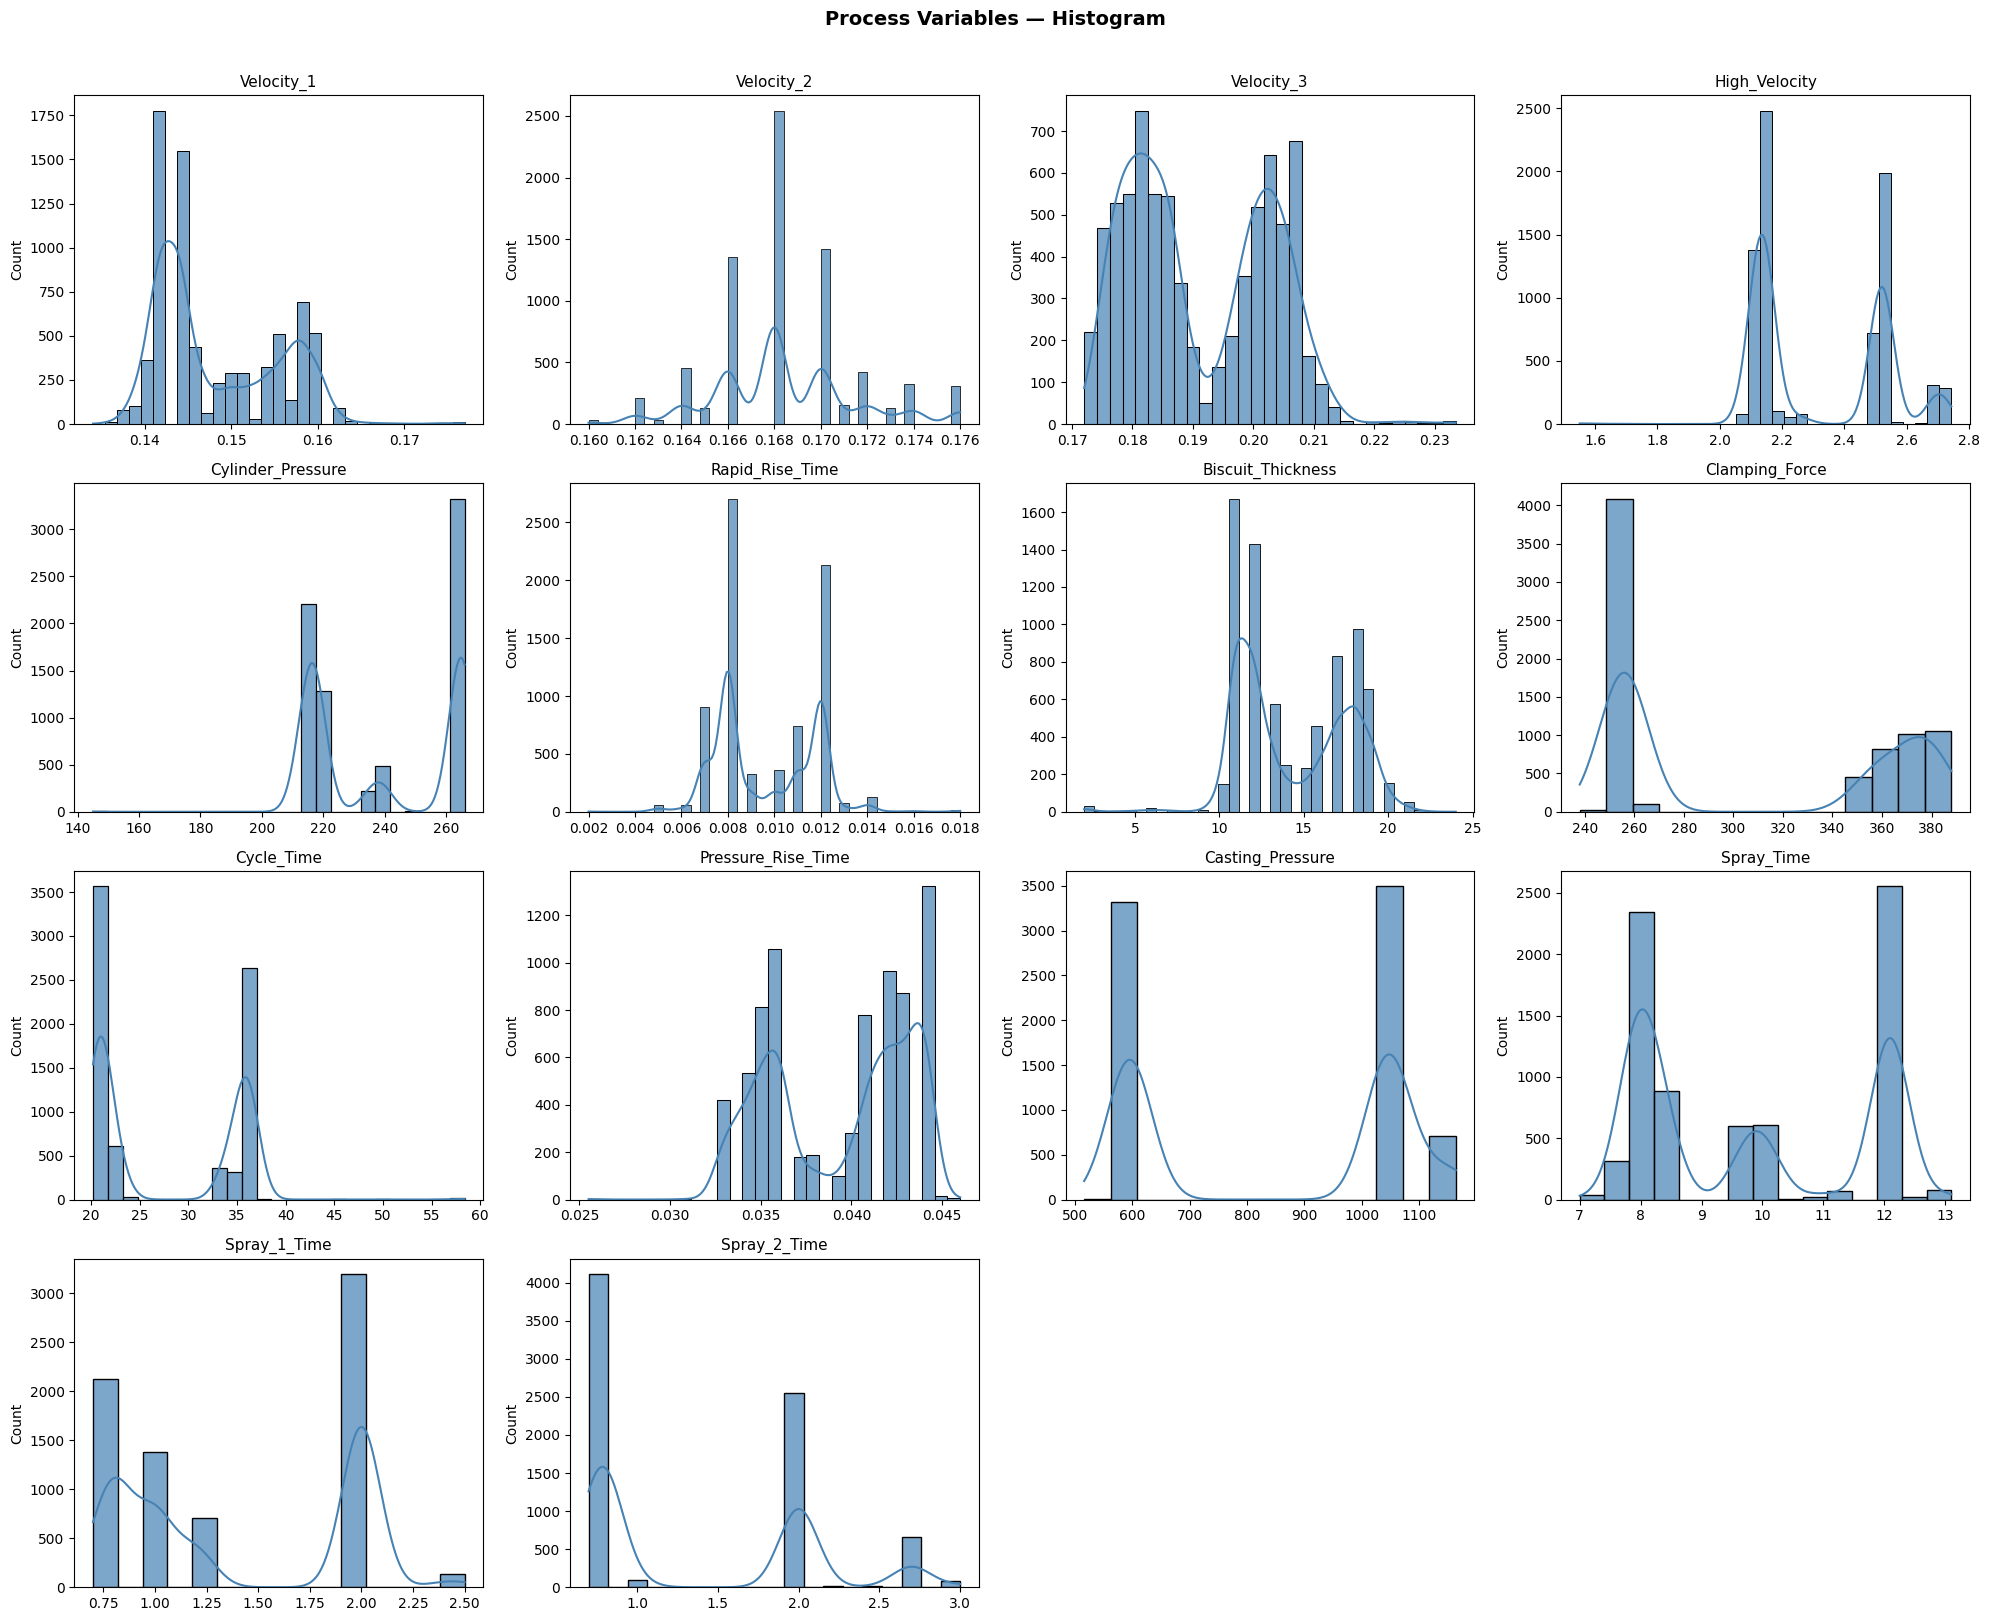

In [18]:
cols    = process_num_cols
n_cols  = 4
n_rows  = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Process Variables — Histogram', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

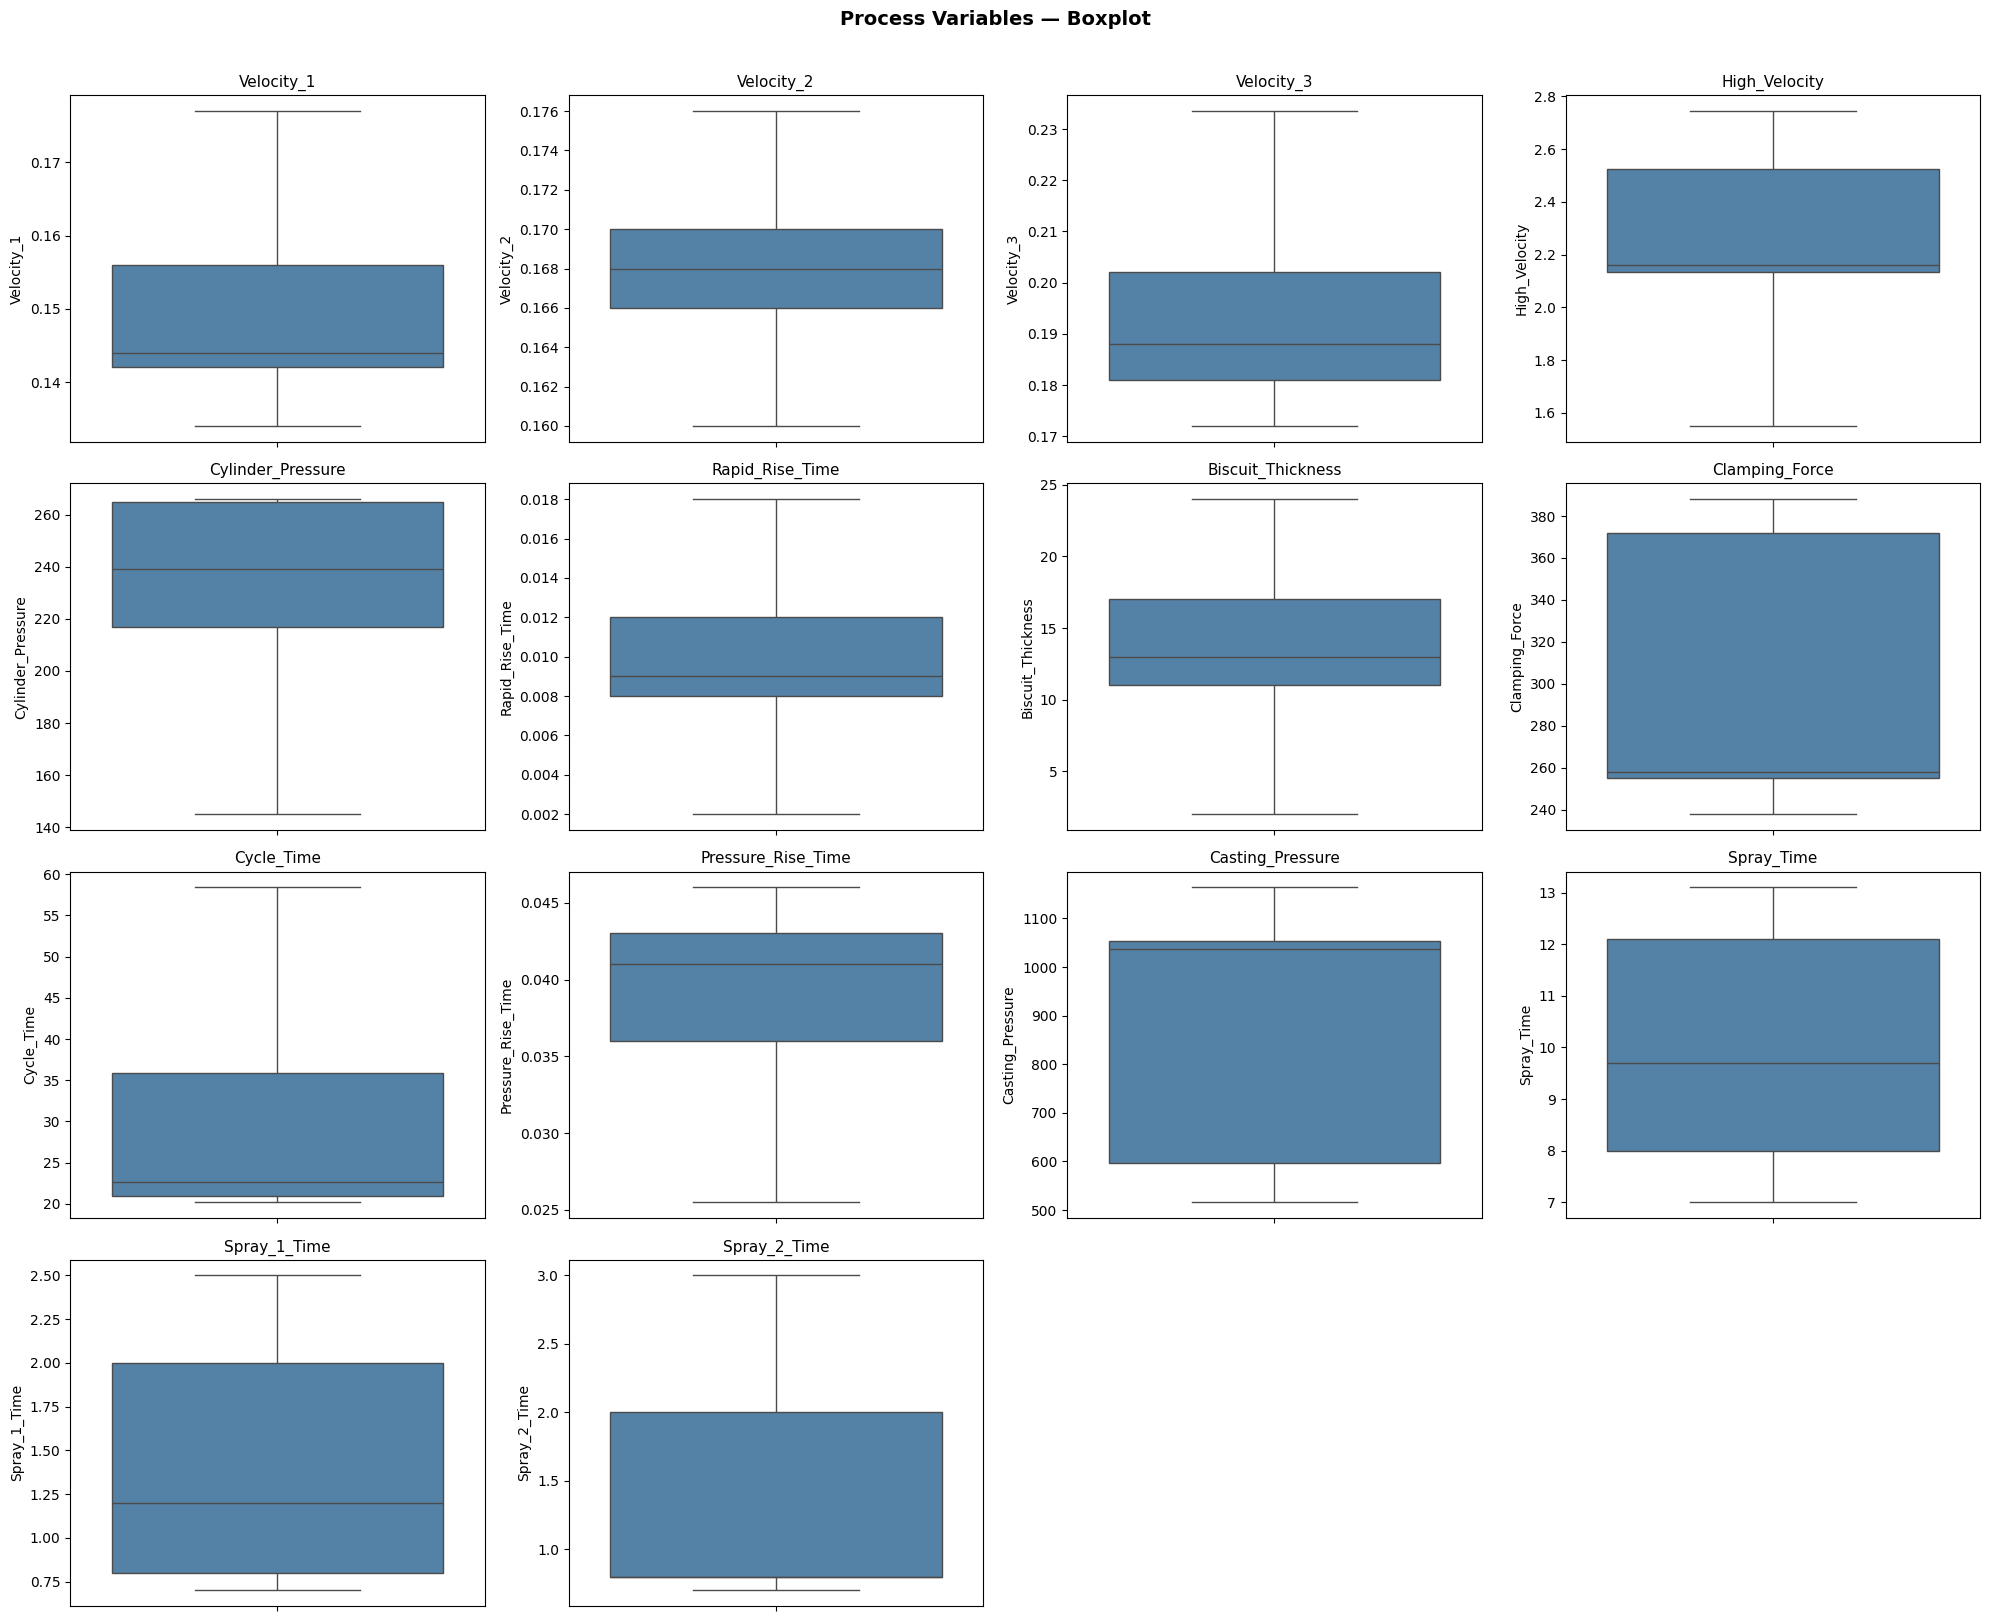

In [19]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Process Variables — Boxplot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7-2. Sensor 변수 히스토그램 + 박스플롯

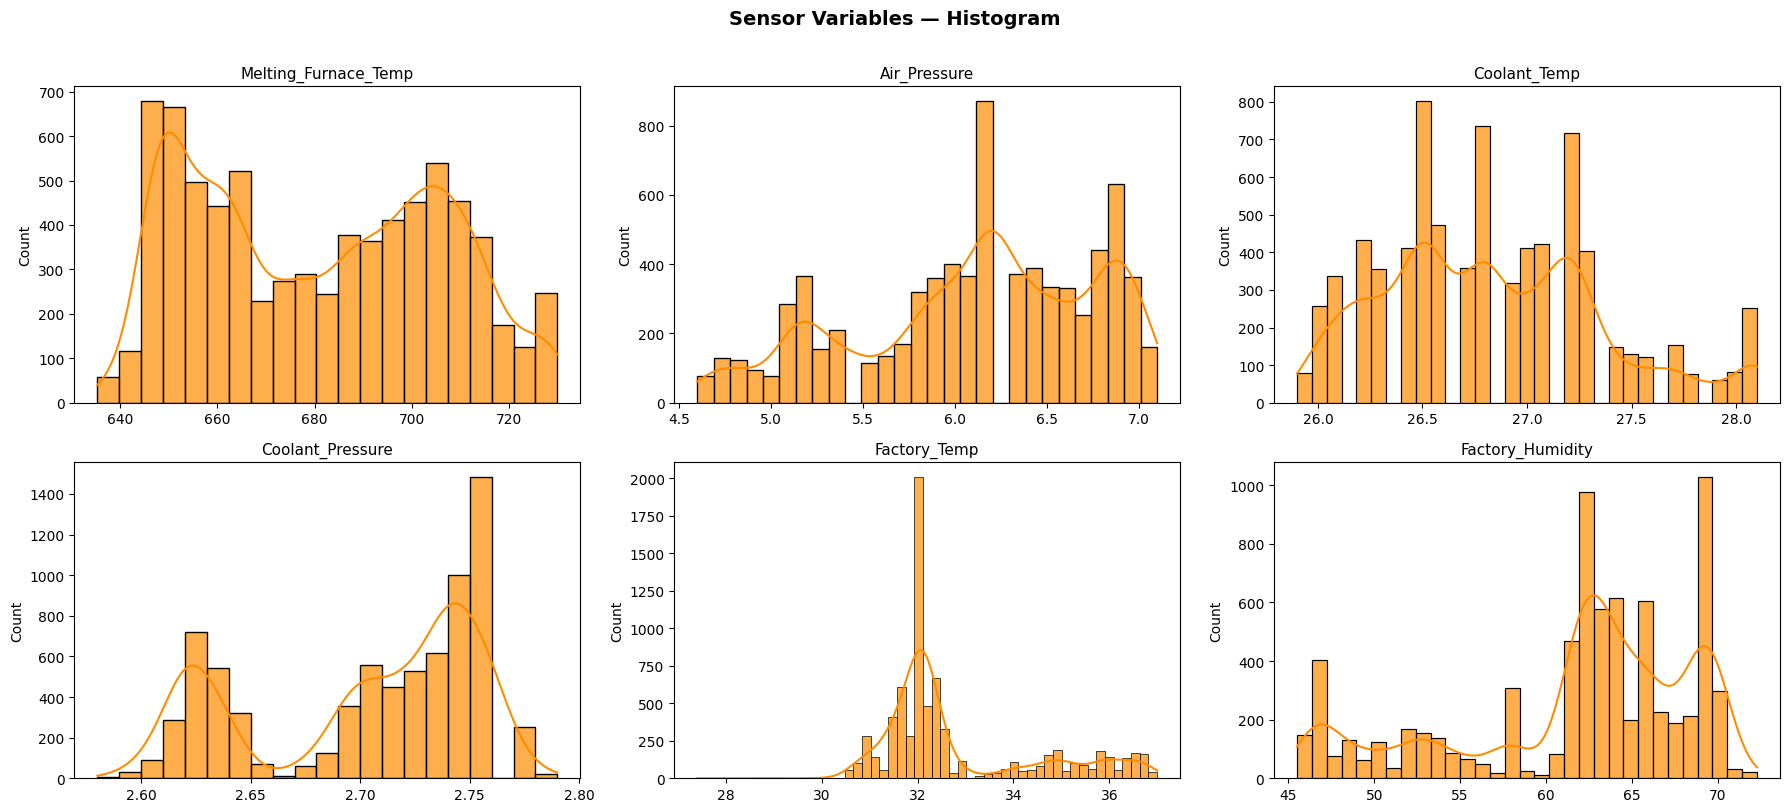

In [20]:
sensor_vis_cols = [
    'Melting_Furnace_Temp', 'Air_Pressure',
    'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity'
]
n_cols_s = 3
n_rows_s = (len(sensor_vis_cols) + n_cols_s - 1) // n_cols_s

fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(18, 4 * n_rows_s))
axes = axes.flatten()

for i, col in enumerate(sensor_vis_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='darkorange', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sensor Variables — Histogram', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

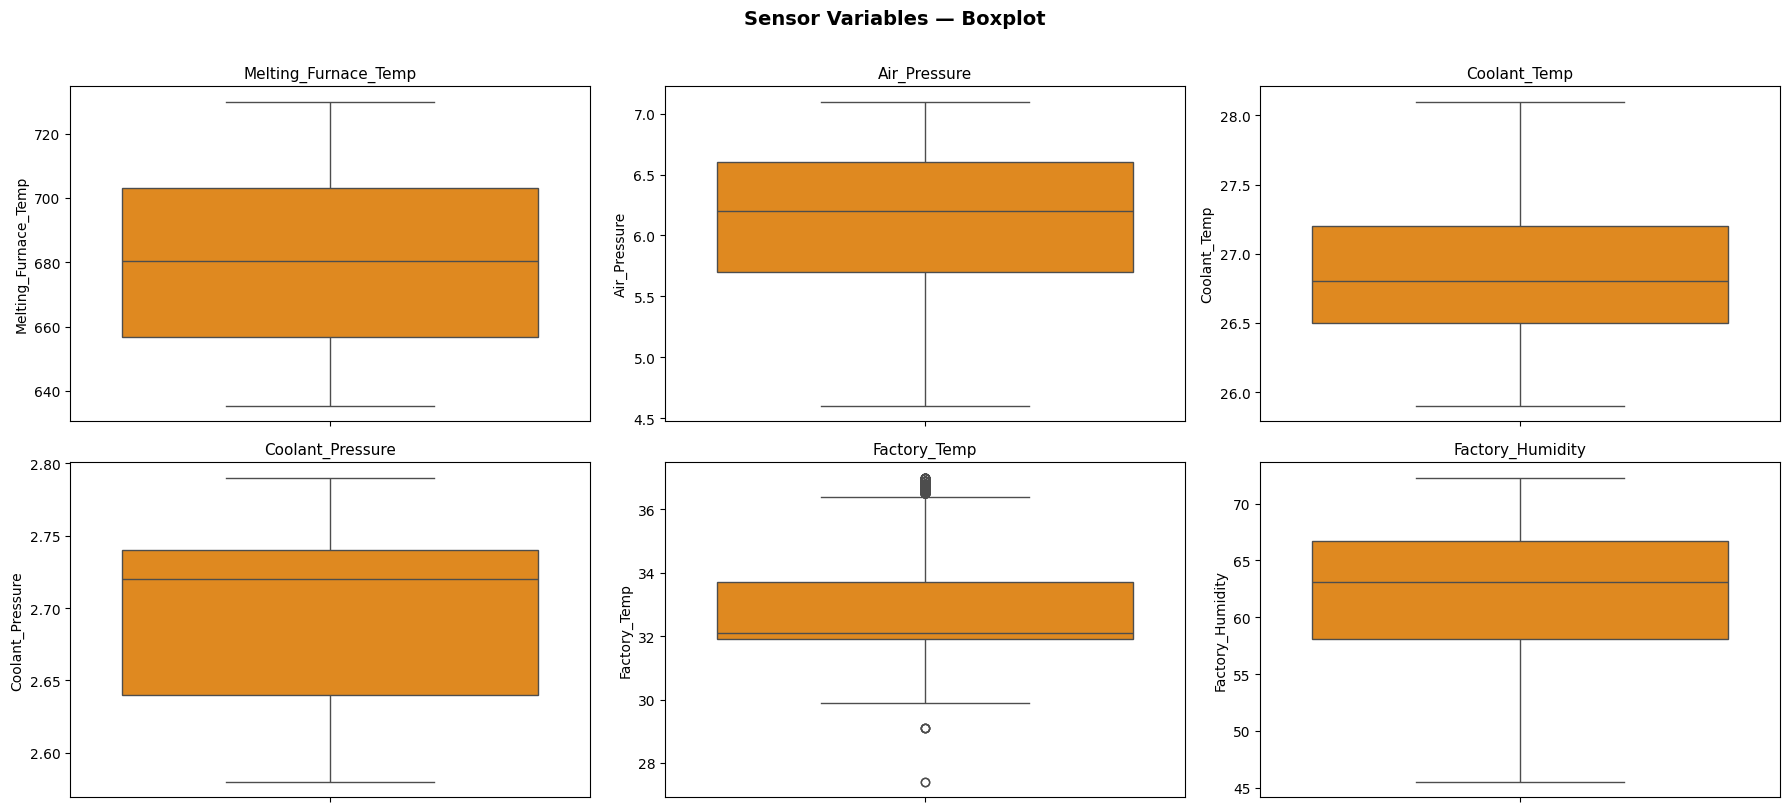

In [21]:
fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(18, 4 * n_rows_s))
axes = axes.flatten()

for i, col in enumerate(sensor_vis_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='darkorange')
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sensor Variables — Boxplot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## STEP 8. 불량 데이터 분포 시각화

/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_19631/1562026349.py:12: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_19631/1562026349.py:12: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_19631/1562026349.py:12: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wc/4jpr72gn34v7gndmn2_zk9680000gn/T/ipykernel_19631/1562026349.py:12: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jisoyun/Desktop/sparta_python/심화 프로젝트/hotsix/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

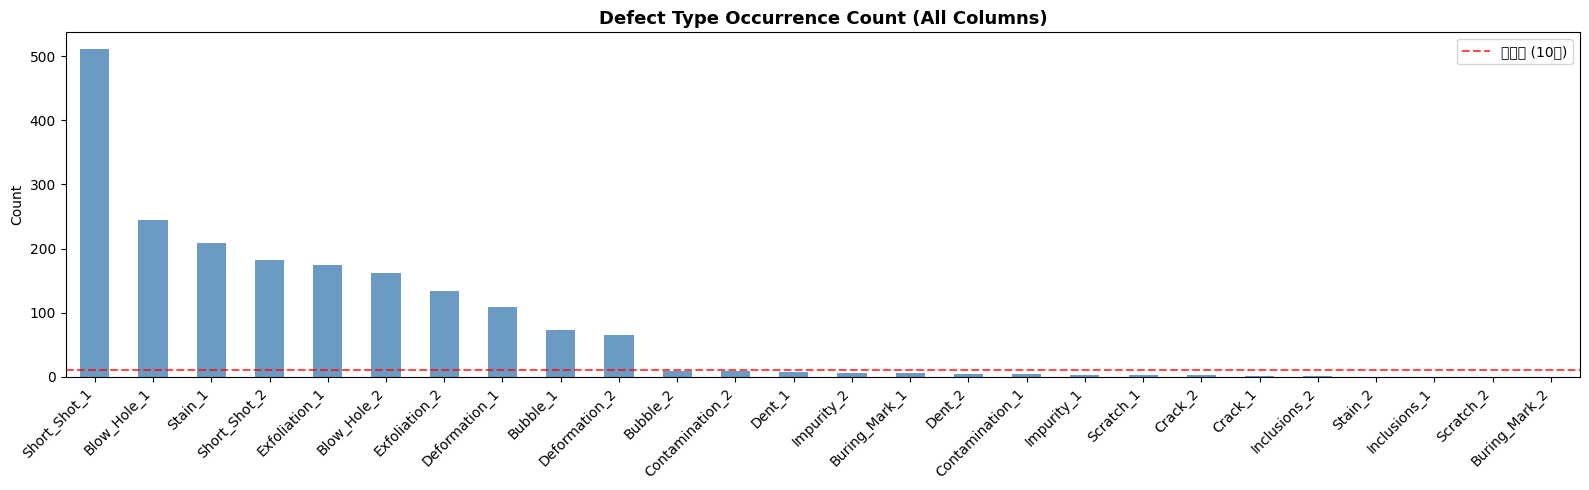

In [22]:
# 불량 유형별 발생 건수 바 차트 (팀원 EDA)
df_defects = df[defect_cols_all].copy()
defect_counts = df_defects.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
defect_counts.plot(kind='bar', color='steelblue', ax=ax, alpha=0.8)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='기준선 (10건)')
ax.set_ylabel('Count')
ax.set_title('Defect Type Occurrence Count (All Columns)', fontsize=13, fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

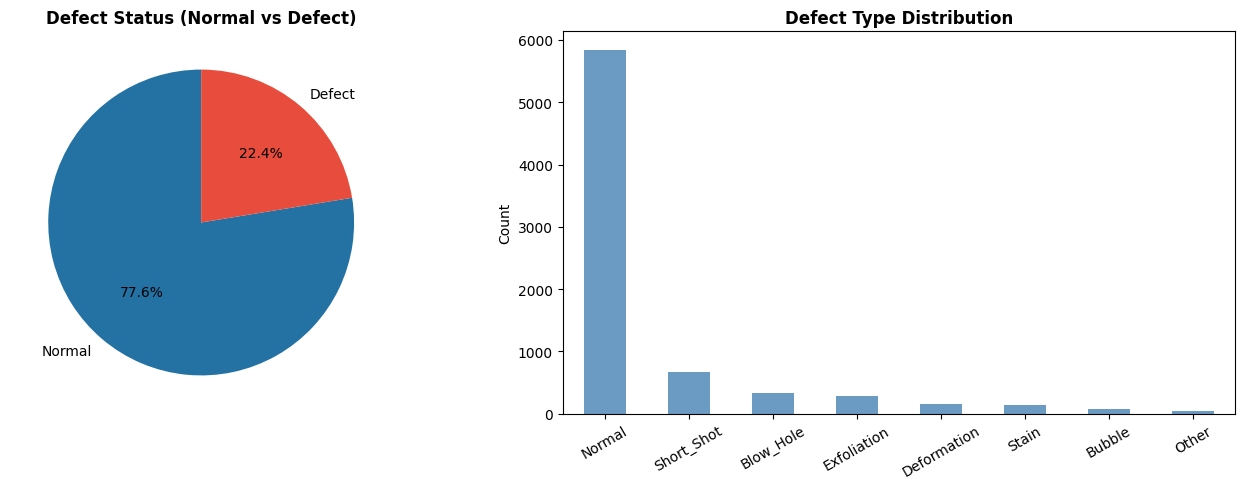


불량률: 22.4%
Defect_Type
Normal         5846
Short_Shot      670
Blow_Hole       333
Exfoliation     283
Deformation     152
Stain           142
Bubble           71
Other            38


In [23]:
# 양품 vs 불량 비율 파이차트 + Defect_Type 막대 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이 차트
status_counts = df['Defect_Status'].value_counts()
axes[0].pie(
    status_counts,
    labels=['Normal', 'Defect'],
    autopct='%1.1f%%',
    colors=['#2471A3', '#E74C3C'],
    startangle=90
)
axes[0].set_title('Defect Status (Normal vs Defect)', fontsize=12, fontweight='bold')

# 불량 유형 막대 차트
type_counts = df['Defect_Type'].value_counts()
type_counts.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Defect Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(df['Defect_Type'].value_counts().to_string())

In [24]:
# Product_Type별 불량률 비교
pt_defect = df.groupby('Product_Type')['Defect_Status'].agg(['sum','count'])
pt_defect['defect_rate(%)'] = (pt_defect['sum'] / pt_defect['count'] * 100).round(2)
pt_defect.columns = ['불량_수', '전체_수', '불량률(%)']
print("Product_Type별 불량 현황:")
display(pt_defect)

Product_Type별 불량 현황:


,불량_수,전체_수,불량률(%)
Product_Type,,,
1,739,4207,17.57
2,950,3328,28.55


## STEP 9. 최종 정제 데이터셋 저장

In [25]:
feature_cols = (
    ['id', 'Product_Type', 'Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity']
    + ['Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range']
    + ['Defect_Status', 'Defect_Type']
)

df_clean = df[feature_cols].copy()
df_clean.to_csv('DieCasting_Preprocessed.csv', index=False)

print(f"✅ 저장 완료: DieCasting_Preprocessed.csv")
print(f"   최종 Shape: {df_clean.shape[0]}행 × {df_clean.shape[1]}열")
print(f"   컬럼: {df_clean.columns.tolist()}")
df_clean.head(5)

✅ 저장 완료: DieCasting_Preprocessed.csv
   최종 Shape: 7535행 × 28열
   컬럼: ['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range', 'Defect_Status', 'Defect_Type']


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Velocity_Avg,Pressure_Diff,Coolant_Temp_Range,Defect_Status,Defect_Type
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,...,6.3,26.0,2.71,32.9,58.4,0.167333,823,40,0,Normal
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,...,6.3,26.1,2.69,32.9,58.2,0.165333,835,40,0,Normal
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,...,6.3,26.1,2.69,32.9,58.2,0.165333,823,40,0,Normal
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,...,6.3,26.1,2.69,32.9,58.2,0.165333,834,40,1,Exfoliation
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,...,6.4,26.1,2.69,32.9,57.8,0.164000,835,40,0,Normal


## STEP 10. 상관분석 — 불량과 상관계수 상위 10개 변수 도출
> Pearson 상관계수 기준으로 Defect_Status와 가장 관련 높은 공정·센서 변수를 선별합니다.

In [26]:
# 분석 피처 정의
analysis_features = (
    process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
       'Factory_Temp', 'Factory_Humidity']
)

# Pearson 상관계수 계산
corr = df[analysis_features + ['Defect_Status']].corr()['Defect_Status'].drop('Defect_Status')

corr_df = pd.DataFrame({
    'variable':    corr.index,
    'correlation': corr.values,
    'abs_corr':    corr.abs().values
}).sort_values('abs_corr', ascending=False).reset_index(drop=True)

corr_df['rank'] = range(1, len(corr_df) + 1)

print("📊 Defect_Status와의 Pearson 상관계수 전체 순위:")
display(corr_df[['rank', 'variable', 'correlation', 'abs_corr']])


📊 Defect_Status와의 Pearson 상관계수 전체 순위:


,rank,variable,correlation,abs_corr
0,1,Melting_Furnace_Temp,-0.145568,0.145568
1,2,Casting_Pressure,-0.145151,0.145151
2,3,Clamping_Force,0.142831,0.142831
3,4,Rapid_Rise_Time,0.133286,0.133286
4,5,Spray_1_Time,0.124848,0.124848
5,6,Cycle_Time,0.123120,0.123120
6,7,Spray_Time,0.110987,0.110987
7,8,Spray_2_Time,0.106157,0.106157
8,9,Biscuit_Thickness,0.095975,0.095975
9,10,High_Velocity,0.093379,0.093379


In [27]:
top10 = corr_df.head(10).copy()

print("🏆 TOP 10 변수 (|상관계수| 기준)")
print("-" * 50)
for _, row in top10.iterrows():
    direction = "▼ 불량 감소" if row['correlation'] < 0 else "▲ 불량 증가"
    print(f"  #{int(row['rank']):>2}  {row['variable']:<25}  {row['correlation']:+.4f}  {direction}")


🏆 TOP 10 변수 (|상관계수| 기준)
--------------------------------------------------
  # 1  Melting_Furnace_Temp       -0.1456  ▼ 불량 감소
  # 2  Casting_Pressure           -0.1452  ▼ 불량 감소
  # 3  Clamping_Force             +0.1428  ▲ 불량 증가
  # 4  Rapid_Rise_Time            +0.1333  ▲ 불량 증가
  # 5  Spray_1_Time               +0.1248  ▲ 불량 증가
  # 6  Cycle_Time                 +0.1231  ▲ 불량 증가
  # 7  Spray_Time                 +0.1110  ▲ 불량 증가
  # 8  Spray_2_Time               +0.1062  ▲ 불량 증가
  # 9  Biscuit_Thickness          +0.0960  ▲ 불량 증가
  #10  High_Velocity              +0.0934  ▲ 불량 증가


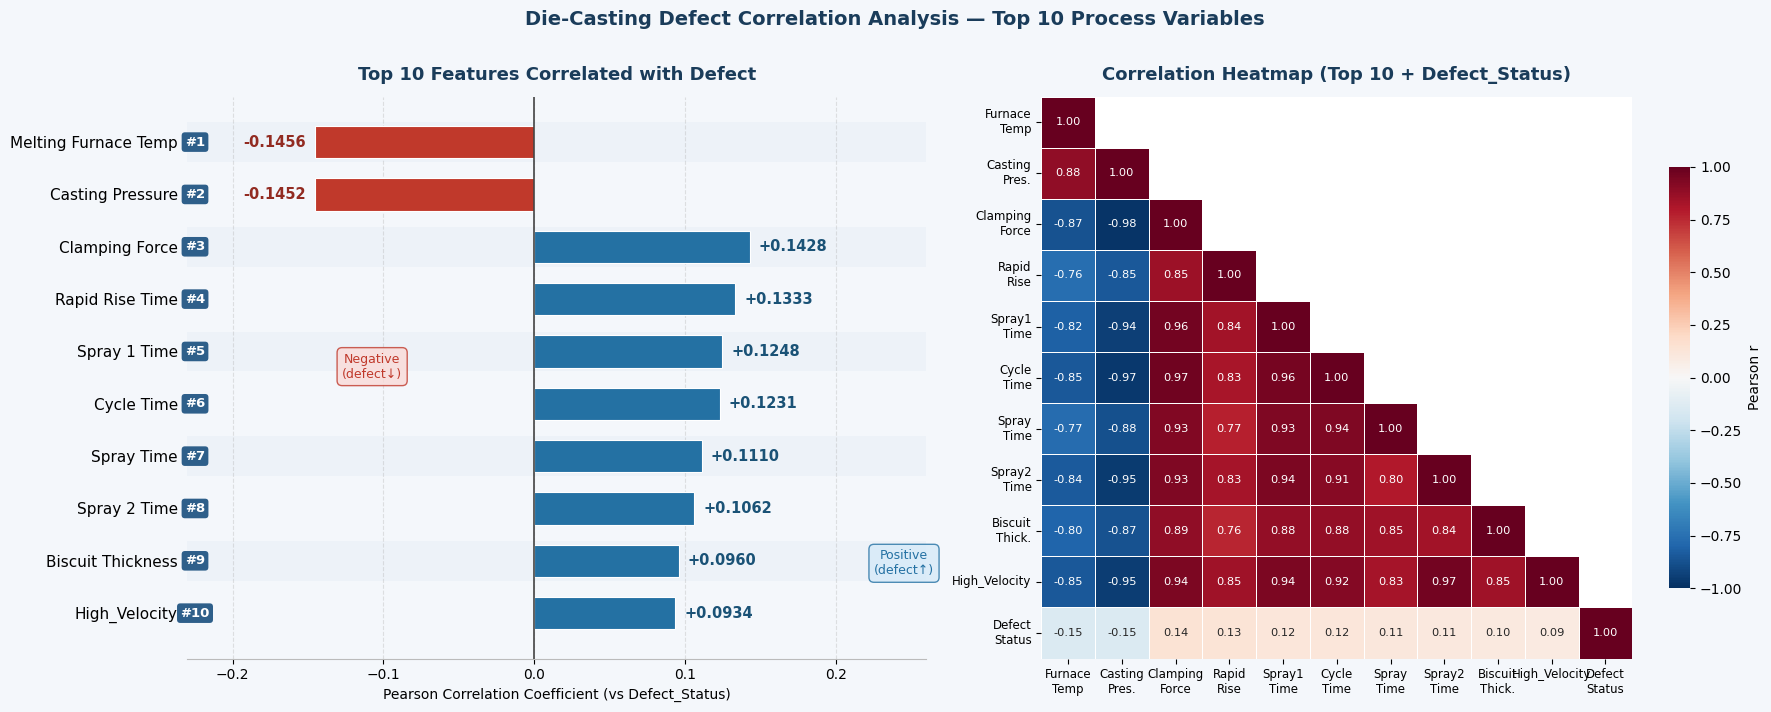

In [33]:
import matplotlib.patches as mpatches

label_map = {
    'Melting_Furnace_Temp': 'Melting Furnace Temp',
    'Casting_Pressure':     'Casting Pressure',
    'Clamping_Force':       'Clamping Force',
    'Rapid_Rise_Time':      'Rapid Rise Time',
    'Spray_1_Time':         'Spray 1 Time',
    'Spray_Time':           'Spray Time',
    'Spray_2_Time':         'Spray 2 Time',
    'Cycle_Time':           'Cycle Time',
    'Biscuit_Thickness':    'Biscuit Thickness',
    'Cylinder_Pressure':    'Cylinder Pressure',
}
top10['label'] = top10['variable'].map(label_map).fillna(top10['variable'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F4F7FB')

# ── 왼쪽: 수평 바 차트
ax1 = axes[0]
ax1.set_facecolor('#F4F7FB')

y_pos  = np.arange(10)[::-1]
colors = ['#C0392B' if v < 0 else '#2471A3' for v in top10['correlation']]

ax1.barh(y_pos, top10['correlation'], color=colors,
         edgecolor='white', linewidth=0.8, height=0.62, zorder=3)

# 배경 줄무늬
for i, yp in enumerate(y_pos):
    ax1.axhspan(yp - 0.38, yp + 0.38,
                facecolor='#E8EFF7' if i % 2 == 0 else '#F4F7FB',
                alpha=0.5, zorder=1)

ax1.axvline(0, color='#444', linewidth=1.2, zorder=4)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top10['label'], fontsize=11)
ax1.set_xlabel('Pearson Correlation Coefficient (vs Defect_Status)', fontsize=10)
ax1.set_title('Top 10 Features Correlated with Defect', fontsize=13, fontweight='bold', color='#1A3C5A', pad=12)
ax1.set_xlim(-0.23, 0.26)
ax1.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
ax1.tick_params(left=False)
for spine in ['top', 'right', 'left']:
    ax1.spines[spine].set_visible(False)
ax1.spines['bottom'].set_color('#BBBBBB')

# 수치 레이블
for yp, val in zip(y_pos, top10['correlation']):
    xoff = 0.006 if val >= 0 else -0.006
    ha   = 'left'  if val >= 0 else 'right'
    col  = '#1A5276' if val >= 0 else '#922B21'
    ax1.text(val + xoff, yp, f'{val:+.4f}', va='center', ha=ha,
             fontsize=10.5, fontweight='bold', color=col, zorder=5)

# 순위 뱃지
for yp, rank in zip(y_pos, top10['rank']):
    ax1.text(-0.225, yp, f'#{int(rank)}', va='center', ha='center',
             fontsize=9.5, color='white', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', facecolor='#2E5F8A', edgecolor='none'))

# 방향 박스
ax1.text(0.97, 0.15, 'Positive\n(defect↑)',
         transform=ax1.transAxes, fontsize=9, color='#2471A3', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#D6EAF8', edgecolor='#2471A3', alpha=0.8))
ax1.text(0.25, 0.5, 'Negative\n(defect↓)',
         transform=ax1.transAxes, fontsize=9, color='#C0392B', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FADBD8', edgecolor='#C0392B', alpha=0.8))

# ── 오른쪽: 히트맵
ax2 = axes[1]
top10_vars = top10['variable'].tolist()
corr_mat   = df[top10_vars + ['Defect_Status']].corr()

short_map = {
    'Melting_Furnace_Temp': 'Furnace\nTemp',
    'Casting_Pressure':     'Casting\nPres.',
    'Clamping_Force':       'Clamping\nForce',
    'Rapid_Rise_Time':      'Rapid\nRise',
    'Spray_1_Time':         'Spray1\nTime',
    'Spray_Time':           'Spray\nTime',
    'Spray_2_Time':         'Spray2\nTime',
    'Cycle_Time':           'Cycle\nTime',
    'Biscuit_Thickness':    'Biscuit\nThick.',
    'Cylinder_Pressure':    'Cylinder\nPres.',
    'Defect_Status':        'Defect\nStatus',
}
corr_mat.index   = [short_map.get(c, c) for c in corr_mat.index]
corr_mat.columns = [short_map.get(c, c) for c in corr_mat.columns]

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=ax2, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.6, linecolor='white',
            annot_kws={'size': 8.2},
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax2.set_title('Correlation Heatmap (Top 10 + Defect_Status)',
              fontsize=13, fontweight='bold', color='#1A3C5A', pad=12)
ax2.tick_params(axis='x', labelsize=8.5, rotation=0)
ax2.tick_params(axis='y', labelsize=8.5, rotation=0)

fig.suptitle('Die-Casting Defect Correlation Analysis — Top 10 Process Variables',
             fontsize=14, fontweight='bold', color='#1A3C5A', y=1.01)
plt.tight_layout()
plt.show()


### 📌 상관분석 주요 인사이트

| 방향 | 변수 | 상관계수 | 해석 |
|---|---|---|---|
| 🔵 음의 상관 | Melting_Furnace_Temp | -0.146 | 용해로 온도 높을수록 불량 감소 — 적정 온도 유지 중요 |
| 🔵 음의 상관 | Casting_Pressure | -0.145 | 주조 압력 높을수록 불량 감소 — 압력 부족이 불량 유발 |
| 🔴 양의 상관 | Clamping_Force | +0.143 | 형체력 과다 시 불량 증가 |
| 🔴 양의 상관 | Rapid_Rise_Time | +0.133 | 압력 응답 지연 시 불량 증가 |
| 🔴 양의 상관 | Spray 계열 3개 | +0.11~0.12 | 이형제 분사 시간 과다 시 불량 증가 |

> ⚠️ **전체 상관계수 절댓값 0.15 이하** → 단일 변수보다 복합 변수 상호작용이 불량을 결정
> → 머신러닝 기반 **다변량 모델**이 필요한 이유